<a href="https://colab.research.google.com/github/farrelrassya/Practical-Statistics-for-Data-Scientist-Books/blob/main/PracticalStatisticsChapter6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6: Statistical Machine Learning

This notebook is a comprehensive companion to **Chapter 6** of *Practical Statistics for Data Scientists* (Bruce, Bruce & Gedeck, 2nd Edition). We explore the core algorithms of **statistical machine learning** -- methods that learn flexible, data-driven decision boundaries rather than imposing a fixed parametric structure on the data.

The chapter covers four major topics, each building on the last:

1. **K-Nearest Neighbors (KNN)** -- classify by analogy: find similar records and vote.
2. **Decision Trees (CART)** -- learn interpretable if-then rules via recursive partitioning.
3. **Random Forests** -- bag many decorrelated trees for variance reduction.
4. **Boosting (XGBoost)** -- sequentially correct errors for maximum predictive power.

We use **LendingClub peer-to-peer loan data** throughout, predicting whether a borrower will **pay off** or **default** on a personal loan -- a canonical binary classification problem in credit risk modeling.

**Python-only implementation.** All code uses scikit-learn, XGBoost, and the `dmba` companion package.

## Setup and Imports

In [1]:
!pip install dmba

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 51.3 MB/s eta 0:00:00


In [2]:
import math
import os
import random
from pathlib import Path
from collections import defaultdict
from itertools import product

import pandas as pd
import numpy as np

from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from dmba import plotDecisionTree, textDecisionTree

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import warnings; warnings.filterwarnings('ignore')

print("All libraries loaded successfully.")
print(f"scikit-learn: {__import__('sklearn').__version__}")
print(f"XGBoost: {__import__('xgboost').__version__}")


Colab environment detected.
All libraries loaded successfully.
scikit-learn: 1.6.1
XGBoost: 3.2.0


We import scikit-learn for KNN, decision trees, and random forests; **XGBoost** for gradient boosting; and the `dmba` companion package for tree visualization utilities. On Google Colab, install missing packages with `!pip install dmba xgboost`.

### Load Data

The textbook provides three subsets of LendingClub data:
- `loan200` -- 200 records for the introductory KNN example
- `loan3000` -- 3,000 records for tree model demonstrations
- `loan_data` -- the full dataset (~45,000 records) for random forest and boosting

In [3]:
# # On Colab, point DATA to the book's GitHub data directory:
# if not os.path.exists('psfds'):
#     !git clone --depth 1 https://github.com/gedeck/practical-statistics-for-data-scientists.git psfds

# DATA = 'psfds/data'
# loan200 = pd.read_csv(f'{DATA}/loan200.csv')

# DATA = Path('.')  # local path -- adapt as needed

# LOAN200_CSV = DATA / 'loan200.csv'
# LOAN3000_CSV = DATA / 'loan3000.csv'
# LOAN_DATA_CSV = DATA / 'loan_data.csv.gz'

# loan200 = pd.read_csv(LOAN200_CSV)
# print(f"loan200:    {loan200.shape[0]} records x {loan200.shape[1]} columns")
# print(f"Columns: {list(loan200.columns)}")
# print(loan200.head(3))


In [4]:
# Clone the book's data repository (runs once)
import os
if not os.path.exists('psfds'):
    !git clone --depth 1 https://github.com/gedeck/practical-statistics-for-data-scientists.git psfds

DATA = 'psfds/data'
LOAN200_CSV = f'{DATA}/loan200.csv'
LOAN3000_CSV = f'{DATA}/loan3000.csv'
LOAN_DATA_CSV = f'{DATA}/loan_data.csv.gz'

loan200 = pd.read_csv(f'{DATA}/loan200.csv')
print(f"loan200:    {loan200.shape[0]} records x {loan200.shape[1]} columns")
print(f"Columns: {list(loan200.columns)}")
print(loan200.head(3))

Cloning into 'psfds'...
remote: Enumerating objects: 98, done.
remote: Counting objects: 100% (98/98), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 98 (delta 3), reused 68 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (98/98), 36.85 MiB | 9.65 MiB/s, done.
Resolving deltas: 100% (3/3), done.
loan200:    201 records x 3 columns
Columns: ['outcome', 'payment_inc_ratio', 'dti']
    outcome  payment_inc_ratio    dti
0    target            9.00000  22.50
1   default            5.46933  21.33
2  paid off            6.90294   8.97


The `loan200` dataset is small enough to visualize the KNN neighborhood in two dimensions. Each record has a known `outcome` (paid off or default) along with financial features like `dti` (debt-to-income ratio) and `payment_inc_ratio` (loan payment relative to income).

## K-Nearest Neighbors

The idea behind **K-Nearest Neighbors (KNN)** is the simplest in all of machine learning:

> *To predict the outcome for a new record, find the $K$ most similar records in the training data and let them vote.*

For **classification**, the majority class among the $K$ neighbors becomes the prediction. For **regression**, we take their average. There is no model to "fit" -- KNN is a **lazy learner** that defers all computation to prediction time.

### A Small Example: Predicting Loan Default

We use two predictor variables -- `payment_inc_ratio` and `dti` -- with $K = 20$ neighbors.

In [5]:
predictors = ['payment_inc_ratio', 'dti']
outcome = 'outcome'

newloan = loan200.loc[0:0, predictors]
X = loan200.loc[1:, predictors]
y = loan200.loc[1:, outcome]

knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X, y)
knn.predict(newloan)
print("Probability estimates [P(paid off), P(default)]:")
print(knn.predict_proba(newloan))


Probability estimates [P(paid off), P(default)]:
[[0.45 0.55]]


The output `[[0.45 0.55]]` tells us that among the $20$ nearest neighbors, $9$ defaulted and $11$ paid off. Since $11/20 = 0.55 > 0.50$, the majority-vote prediction is **"paid off."**

The probability estimate is computed as:

$$P(\text{class} = c) = \frac{\text{\# neighbors in class } c}{K}$$

This probability is more informative than the binary prediction alone. A loan with $P(\text{default}) = 0.45$ is very different from one with $P(\text{default}) = 0.05$, even though both are predicted as "paid off." In credit risk, we would feed this probability into a **risk-scoring system** where the threshold can be adjusted based on business objectives -- a conservative lender might reject anything above $P(\text{default}) > 0.30$.

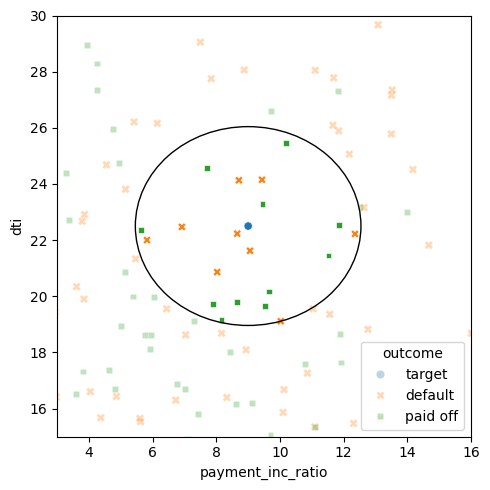

In [6]:
nbrs = knn.kneighbors(newloan)
maxDistance = np.max(nbrs[0][0])

fig, ax = plt.subplots(figsize=(5, 5))
sns.scatterplot(x='payment_inc_ratio', y='dti', style='outcome',
                hue='outcome', data=loan200, alpha=0.3, ax=ax)
sns.scatterplot(x='payment_inc_ratio', y='dti', style='outcome',
                hue='outcome',
                data=pd.concat([loan200.loc[0:0, :], loan200.loc[nbrs[1][0] + 1,:]]),
                ax=ax, legend=False)
ellipse = Ellipse(xy=newloan.values[0],
                  width=2 * maxDistance, height=2 * maxDistance,
                  edgecolor='black', fc='None', lw=1)
ax.add_patch(ellipse)
ax.set_xlim(3, 16)
ax.set_ylim(15, 30)

plt.tight_layout()
plt.show()


The ellipse shows the boundary enclosing the $20$ nearest neighbors. The new loan sits at the center, and the algorithm simply counts how many of the circled points are defaults (circles) versus paid off (squares). This is the essence of KNN: **local voting** based on proximity.

**What would change with different $K$?**
- $K = 3$: A tiny neighborhood -- highly sensitive to the nearest few points. If the three closest loans happen to be defaults (even by chance), the prediction flips. This is **high variance**.
- $K = 100$: The circle expands to cover half the dataset, washing out local structure. This is **high bias** -- the prediction converges toward the overall base rate.

The tension between these extremes is the **bias-variance tradeoff**, one of the most fundamental concepts in machine learning:

$$\text{Total Error} = \underbrace{\text{Bias}^2}_{\text{underfitting}} + \underbrace{\text{Variance}}_{\text{overfitting}} + \underbrace{\sigma^2}_{\text{irreducible noise}}$$

### Standardization (Normalization, Z-Scores)

**Why is feature scaling essential for KNN?** Because Euclidean distance treats all features equally in their raw units. If one feature ranges from $0$ to $\$200{,}000$ (like `revol_bal`) while another ranges from $0$ to $40$ (like `dti`), the high-magnitude feature will **completely dominate** the distance calculation, making the other features invisible.

**Standardization** transforms each feature to have zero mean and unit variance:

$$z = \frac{x - \bar{x}}{s}$$

where $\bar{x}$ is the mean and $s$ is the standard deviation. After this transformation, all features contribute proportionally to the distance metric.

In [7]:
loan_data = pd.read_csv(LOAN_DATA_CSV)
loan_data = loan_data.drop(columns=['Unnamed: 0', 'status'])
loan_data['outcome'] = pd.Categorical(loan_data['outcome'],
                                      categories=['paid off', 'default'],
                                      ordered=True)

predictors = ['payment_inc_ratio', 'dti', 'revol_bal', 'revol_util']
outcome = 'outcome'

newloan = loan_data.loc[0:0, predictors]
print("New loan to predict:")
print(newloan)
X = loan_data.loc[1:, predictors]
y = loan_data.loc[1:, outcome]

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)

nbrs = knn.kneighbors(newloan)
print("\n5 Nearest Neighbors WITHOUT Standardization:")
print(X.iloc[nbrs[1][0], :])


New loan to predict:
   payment_inc_ratio  dti  revol_bal  revol_util
0             2.3932  1.0       1687         9.4

5 Nearest Neighbors WITHOUT Standardization:
       payment_inc_ratio   dti  revol_bal  revol_util
35536            1.47212  1.46       1686        10.0
33651            3.38178  6.37       1688         8.4
25863            2.36303  1.39       1691         3.5
42953            1.28160  7.14       1684         3.9
43599            4.12244  8.98       1684         7.2


**The problem is stark.** The five nearest neighbors all have `revol_bal` values clustered tightly around the new loan's value of $\$1{,}687$, but the other three features are scattered all over the map. A difference of $\$3$ in revolving balance (say, $\$1{,}684$ vs $\$1{,}687$) contributes $3^2 = 9$ to the squared Euclidean distance, while a difference of $5$ in `dti` also contributes only $5^2 = 25$ -- yet the `revol_bal` differences are typically in the thousands, completely overwhelming everything else.

**The result:** `revol_bal` alone determines the neighbors, and the other features -- which may be equally or more predictive -- are effectively ignored.

In [8]:
newloan = loan_data.loc[0:0, predictors]
X = loan_data.loc[1:, predictors]
y = loan_data.loc[1:, outcome]

scaler = preprocessing.StandardScaler()
scaler.fit(X * 1.0)

X_std = scaler.transform(X * 1.0)
newloan_std = scaler.transform(newloan * 1.0)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_std, y)

nbrs = knn.kneighbors(newloan_std)
print("5 Nearest Neighbors WITH Standardization:")
print(X.iloc[nbrs[1][0], :])


5 Nearest Neighbors WITH Standardization:
       payment_inc_ratio   dti  revol_bal  revol_util
2080             2.61091  1.03       1218         9.7
1438             2.34343  0.51        278         9.9
30215            2.71200  1.34       1075         8.5
28542            2.39760  0.74       2917         7.4
44737            2.34309  1.37        488         7.2


After standardization, the five nearest neighbors are genuinely similar across **all four features** -- `payment_inc_ratio`, `dti`, `revol_bal`, and `revol_util` are all close to the new loan's values. Each feature now contributes proportionally to the distance because they are all on the same scale (standard deviations from their respective means).

**Production note:** Always fit the `StandardScaler` on the **training data only**, then apply the learned mean and standard deviation to transform both training and test data. Fitting on the full dataset leaks information from the test set into training -- a subtle but pernicious form of **data leakage** that inflates performance estimates.

### KNN as a Feature Engine

KNN by itself is rarely competitive with more sophisticated classifiers. Its real power in modern workflows is as a **feature engineering tool** -- creating new predictive features that capture local neighborhood information.

The idea is a two-stage process:
1. Run KNN on credit-related features and extract the predicted probability for each record.
2. Feed this `borrower_score` as an additional predictor into a more powerful model.

This is analogous to what a real estate appraiser does with "comparable sales" (comps) -- essentially a manual KNN.

count    45342.000000
mean         0.501098
std          0.128736
min          0.000000
25%          0.400000
50%          0.500000
75%          0.600000
max          0.950000
Name: borrower_score, dtype: float64


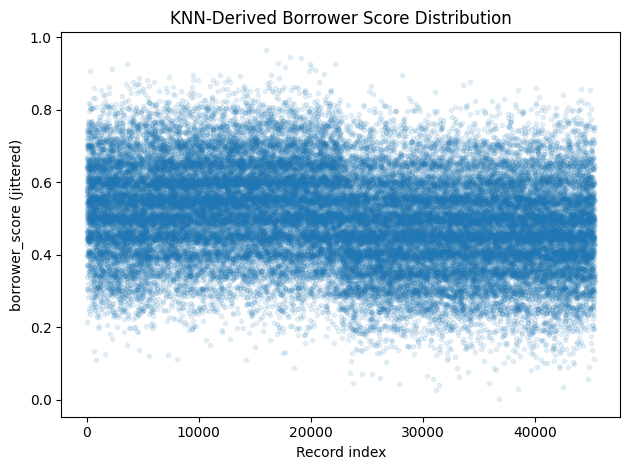

In [9]:
loan_data = pd.read_csv(LOAN_DATA_CSV)
loan_data = loan_data.drop(columns=['Unnamed: 0', 'status'])
loan_data['outcome'] = pd.Categorical(loan_data['outcome'],
                                      categories=['paid off', 'default'],
                                      ordered=True)

predictors = ['dti', 'revol_bal', 'revol_util', 'open_acc',
              'delinq_2yrs_zero', 'pub_rec_zero']
outcome = 'outcome'

X = loan_data[predictors]
y = loan_data[outcome]

knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X, y)
plt.scatter(range(len(X)), [bs + random.gauss(0, 0.015) for bs in knn.predict_proba(X)[:,0]],
            alpha=0.1, marker='.')

loan_data['borrower_score'] = knn.predict_proba(X)[:, 0]
print(loan_data['borrower_score'].describe())

plt.xlabel('Record index')
plt.ylabel('borrower_score (jittered)')
plt.title('KNN-Derived Borrower Score Distribution')
plt.tight_layout()
plt.show()


The `borrower_score` is a KNN-derived feature that distills six credit-related variables into a single number between $0$ and $1$. Each score represents the fraction of the $K = 20$ nearest neighbors (in credit-history space) who paid off their loans.

The summary statistics reveal a roughly symmetric distribution centered around $0.50$ with a standard deviation of $0.129$:
- A score of $0.95$ means that $19$ out of $20$ similar borrowers paid off -- very creditworthy.
- A score of $0.00$ means all $20$ nearest credit-history neighbors defaulted -- extremely high risk.
- The median of $0.50$ reflects the roughly balanced class distribution in this dataset.

The scatter plot shows the score varies considerably across records, with most concentrated in the $[0.35, 0.65]$ range. This feature captures **local creditworthiness** and will prove to be the single most important predictor in the tree and ensemble models that follow.

**Why this is not multicollinearity:** The KNN feature encodes highly **local** information -- the behavior of a handful of nearby records -- which is fundamentally different from the global relationships captured by the raw features.

## Tree Models

**Decision trees** are perhaps the most interpretable machine learning model. A tree model is a nested set of **if-then-else rules** that recursively partition the data into increasingly homogeneous groups. The result is a flowchart that anyone -- from a data scientist to a loan officer to a regulator -- can follow.

### A Simple Example

We fit a decision tree to `loan3000` using `borrower_score` and `payment_inc_ratio`.

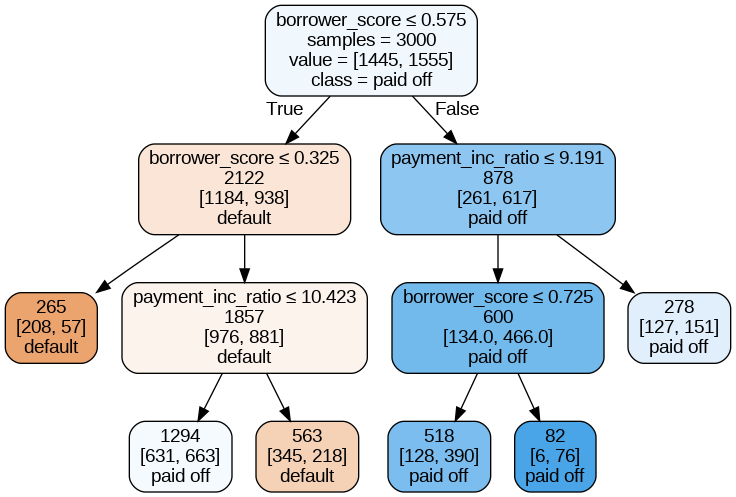

In [10]:
loan3000 = pd.read_csv(LOAN3000_CSV)

predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = loan3000[outcome]

loan_tree = DecisionTreeClassifier(random_state=1, criterion='entropy',
                                   min_impurity_decrease=0.003)
loan_tree.fit(X, y)
plotDecisionTree(loan_tree, feature_names=predictors, class_names=loan_tree.classes_)


This is the decision tree shown in **Figure 6-3** of the textbook. Let us trace through it completely, because understanding how to read a tree is fundamental to everything that follows.

**How to traverse the tree:** Start at the **root** (top node). At each decision node, evaluate the condition. Go **left if TRUE**, go **right if FALSE**. Continue until you reach a **leaf** (terminal node), which gives the prediction.

### Reading Figure 6-3: A Complete Walkthrough

**Level 1 -- The root split: `borrower_score >= 0.575`**

This single feature is the most discriminating split the algorithm could find across all features and all possible thresholds. It divides the data into two groups:
- **Left (True -- score $\geq 0.575$):** These are creditworthy borrowers. The tree predicts **"paid off"** immediately, without examining any other feature. About $70\%$ of records in this partition actually paid off (from the textbook: $878$ records, $261$ misclassified, so accuracy $\approx 70.3\%$).
- **Right (False -- score $< 0.575$):** These are higher-risk borrowers who need further examination.

**Why $0.575$?** The algorithm tried every possible threshold for every feature and selected the one that maximizes the reduction in **entropy** (class mixing). At $0.575$, the left partition becomes substantially purer than the original data.

**Level 2 -- Second split: `borrower_score >= 0.375`**

For the remaining records (score $< 0.575$), the tree asks a second question about creditworthiness:
- **Right (False -- score $< 0.375$):** These borrowers have very poor credit profiles. The tree predicts **"default"** immediately. About $72\%$ of records here actually defaulted -- the tree has learned that below this threshold, no other factor can save them.
- **Left (True -- score between $0.375$ and $0.575$):** The "gray zone" where credit score alone is ambiguous.

**Level 3 -- `payment_inc_ratio < 10.42`**

For borrowers in the gray zone, the tree now examines a completely different dimension: **payment burden**. How large is the loan payment relative to income?
- **Right (False -- ratio $\geq 10.42$):** High payment burden combined with mediocre credit $\rightarrow$ predict **"default."** About $60\%$ of records here defaulted.
- **Left (True -- ratio $< 10.42$):** Manageable payments, so the tree digs one level deeper.

**Levels 4-5 -- Final refinements**

The tree makes two more splits for the moderate-credit, moderate-payment subgroup:
- `payment_inc_ratio < 4.426`: Very low payment burden $\rightarrow$ predict **"paid off."**
- `borrower_score >= 0.475`: For moderate payment burdens ($4.43$ to $10.42$), credit score breaks the tie:
  - Score $\geq 0.475$ $\rightarrow$ **"paid off"** (the slightly-above-average credit tips the balance)
  - Score $< 0.475$ $\rightarrow$ **"default"** (below-average credit + moderate payment = too risky)

### Three Worked Examples

**Example 1 -- Creditworthy borrower:** `borrower_score = 0.6`, `payment_inc_ratio = 8.0`
- Root: $0.6 \geq 0.575$? **Yes** $\rightarrow$ left $\rightarrow$ **Leaf: "paid off."** Done in one step.

**Example 2 -- High-risk borrower:** `borrower_score = 0.3`, `payment_inc_ratio = 12.0`
- Root: $0.3 \geq 0.575$? **No** $\rightarrow$ right.
- Level 2: $0.3 \geq 0.375$? **No** $\rightarrow$ right $\rightarrow$ **Leaf: "default."** Done in two steps.

**Example 3 -- Ambiguous borrower:** `borrower_score = 0.45`, `payment_inc_ratio = 5.0`
- Root: $0.45 \geq 0.575$? **No** $\rightarrow$ right.
- Level 2: $0.45 \geq 0.375$? **Yes** $\rightarrow$ left.
- Level 3: $5.0 < 10.42$? **Yes** $\rightarrow$ left.
- Level 4: $5.0 < 4.426$? **No** $\rightarrow$ right.
- Level 5: $0.45 \geq 0.475$? **No** $\rightarrow$ right $\rightarrow$ **Leaf: "default."**

This borrower needed **five decision points** to classify. The score of $0.45$ falls just below the $0.475$ threshold at the final split, tipping the prediction. A slightly higher score of $0.48$ would have changed the outcome to "paid off" -- a razor-thin margin that highlights both the power and fragility of single trees.

### Key Insight: Hierarchy of Importance

The tree discovered that **`borrower_score` is the dominant predictor**, appearing at three out of five decision levels. `payment_inc_ratio` only matters for borrowers in the ambiguous middle range ($0.375 \leq \text{score} < 0.575$). This makes intuitive business sense: a borrower's track record (credit history) is the first thing to check, and payment burden only becomes decisive when creditworthiness is inconclusive.

In [11]:
print(textDecisionTree(loan_tree))


node=0 test node: go to node 1 if 0 <= 0.5750000178813934 else to node 6
  node=1 test node: go to node 2 if 0 <= 0.32500000298023224 else to node 3
    node=2 leaf node: [[np.float64(0.785), np.float64(0.215)]]
    node=3 test node: go to node 4 if 1 <= 10.42264986038208 else to node 5
      node=4 leaf node: [[np.float64(0.488), np.float64(0.512)]]
      node=5 leaf node: [[np.float64(0.613), np.float64(0.387)]]
  node=6 test node: go to node 7 if 1 <= 9.19082498550415 else to node 10
    node=7 test node: go to node 8 if 0 <= 0.7249999940395355 else to node 9
      node=8 leaf node: [[np.float64(0.247), np.float64(0.753)]]
      node=9 leaf node: [[np.float64(0.073), np.float64(0.927)]]
    node=10 leaf node: [[np.float64(0.457), np.float64(0.543)]]


The text representation encodes the same tree in a machine-readable format. Each node shows:
- **Feature index** ($0$ = `borrower_score`, $1$ = `payment_inc_ratio`)
- **Threshold** (the split value)
- **Leaf probabilities** as $[P(\text{default}), P(\text{paid off})]$

For example, `node=9 leaf node: [[0.073, 0.927]]` means that partition contains $92.7\%$ "paid off" records -- an extremely pure leaf corresponding to borrowers with high credit scores and low payment burdens.

### The Recursive Partitioning Algorithm

The tree's if-then rules correspond to **axis-aligned rectangles** in the feature space. Each split draws a vertical or horizontal line, carving the 2D plane into regions.

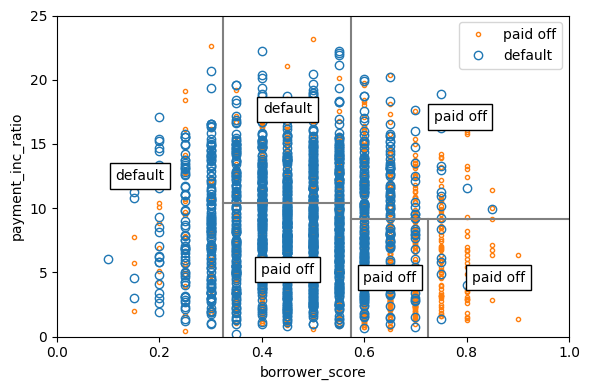

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))

loan3000.loc[loan3000.outcome=='paid off'].plot(
    x='borrower_score', y='payment_inc_ratio', style='.',
    markerfacecolor='none', markeredgecolor='C1', ax=ax)
loan3000.loc[loan3000.outcome=='default'].plot(
    x='borrower_score', y='payment_inc_ratio', style='o',
    markerfacecolor='none', markeredgecolor='C0', ax=ax)
ax.legend(['paid off', 'default']);
ax.set_xlim(0, 1)
ax.set_ylim(0, 25)
ax.set_xlabel('borrower_score')
ax.set_ylabel('payment_inc_ratio')

x0 = 0.575
x1a = 0.325; y1b = 9.191
y2a = 10.423; x2b = 0.725
ax.plot((x0, x0), (0, 25), color='grey')
ax.plot((x1a, x1a), (0, 25), color='grey')
ax.plot((x0, 1), (y1b, y1b), color='grey')
ax.plot((x1a, x0), (y2a, y2a), color='grey')
ax.plot((x2b, x2b), (0, y1b), color='grey')

labels = [('default', (x1a / 2, 25 / 2)),
          ('default', ((x0 + x1a) / 2, (25 + y2a) / 2)),
          ('paid off', ((x0 + x1a) / 2, y2a / 2)),
          ('paid off', ((1 + x0) / 2, (y1b + 25) / 2)),
          ('paid off', ((1 + x2b) / 2, (y1b + 0) / 2)),
          ('paid off', ((x0 + x2b) / 2, (y1b + 0) / 2)),
         ]
for label, (x, y) in labels:
    ax.text(x, y, label, bbox={'facecolor':'white'},
            verticalalignment='center', horizontalalignment='center')

plt.tight_layout()
plt.show()


Each gray line corresponds to one split in the tree. The first vertical line at `borrower_score = 0.575` creates the largest partition, separating creditworthy borrowers (right) from the rest. Subsequent splits refine the left region.

Notice that the decision boundary is **piecewise axis-aligned** -- the tree can only make cuts parallel to the feature axes. This is fundamentally different from logistic regression (which draws a single diagonal line) and is both a strength (captures nonlinear interactions) and a limitation (cannot model diagonal boundaries efficiently).

**The algorithm that creates these partitions** is called **recursive partitioning**. At each step, it:
1. Considers every feature and every possible threshold.
2. Evaluates the resulting split using an **impurity measure** (how mixed are the classes in each child partition?).
3. Selects the split that maximizes **purity gain**.
4. Recurses on each child partition until a stopping criterion is met.

### Measuring Homogeneity or Impurity

How does the tree decide which split is best? It needs to measure **impurity** -- how mixed the classes are within each partition. Let $p$ be the proportion of the positive class in a partition.

**Gini impurity:** $\quad I_{\text{Gini}}(A) = p(1 - p)$

**Entropy:** $\quad I_{\text{entropy}}(A) = -p \log_2 p - (1-p) \log_2 (1-p)$

Both are zero when a partition is **pure** ($p = 0$ or $p = 1$) and maximum when $p = 0.5$ (a coin flip). The tree selects the split that minimizes the **weighted average impurity** across both child partitions:

$$I_{\text{split}} = \frac{|A_{\text{left}}|}{|A|} \cdot I(A_{\text{left}}) + \frac{|A_{\text{right}}|}{|A|} \cdot I(A_{\text{right}})$$

In [13]:
def entropyFunction(x):
    if x == 0: return 0
    return -x * math.log(x, 2) - (1 - x) * math.log(1 - x, 2)

def giniFunction(x):
    return x * (1 - x)


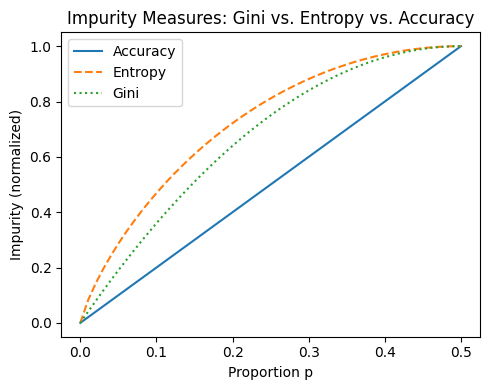

In [14]:
x = np.linspace(0, 0.5, 50)
impure = pd.DataFrame({
    'x': x,
    'Accuracy': 2 * x,
    'Gini': [giniFunction(xi) / giniFunction(.5) for xi in x],
    'Entropy': [entropyFunction(xi) for xi in x],
})

fig, ax = plt.subplots(figsize=(5, 4))

impure.plot(x='x', y='Accuracy', ax=ax, linestyle='solid')
impure.plot(x='x', y='Entropy', ax=ax, linestyle='--')
impure.plot(x='x', y='Gini', ax=ax, linestyle=':')

ax.set_xlabel('Proportion p')
ax.set_ylabel('Impurity (normalized)')
ax.set_title('Impurity Measures: Gini vs. Entropy vs. Accuracy')
plt.tight_layout()
plt.show()


The three curves are similar in shape but differ subtly. **Accuracy** (misclassification rate) is linear and is actually a poor measure for splitting because it does not reward "confident" splits. **Gini** and **Entropy** are concave, meaning they give extra credit for making already-pure partitions even purer -- exactly the behavior we want.

In practice, Gini and Entropy almost always produce identical trees. scikit-learn defaults to Gini; the textbook uses `criterion='entropy'`. The choice rarely affects final predictive performance.

## Bagging and the Random Forest

A single decision tree is interpretable but fragile -- small changes in the data can produce a completely different tree. The **random forest** addresses this through the "wisdom of crowds": train many diverse trees and let them vote.

It combines two techniques:

1. **Bagging (Bootstrap Aggregating):** Each tree trains on a different bootstrap sample (random sample **with replacement**), ensuring diversity.
2. **Feature subsampling:** At each split, only a random subset of $\sqrt{p}$ features is considered. This **decorrelates** the trees.

The ensemble variance of $B$ models is:

$$\text{Var}\left(\frac{1}{B}\sum_{b=1}^{B} f_b\right) = \rho\sigma^2 + \frac{(1-\rho)\sigma^2}{B}$$

where $\rho$ is the average correlation between trees. Feature subsampling reduces $\rho$, directly reducing ensemble variance. As $B \to \infty$, the second term vanishes.

### Random Forest

In [15]:
predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = loan3000[outcome]

rf = RandomForestClassifier(n_estimators=500, random_state=1,
                            oob_score=True)
rf.fit(X, y)

# Show OOB decision function (first and last few)
oob = rf.oob_decision_function_
print("OOB decision function (first 3 and last 3 records):")
print(oob[:3])
print("...")
print(oob[-3:])
print(f"\nOOB accuracy: {rf.oob_score_:.4f}")
print(f"OOB error rate: {1 - rf.oob_score_:.4f}")


OOB decision function (first 3 and last 3 records):
[[0.18131868 0.81868132]
 [0.26704545 0.73295455]
 [0.93333333 0.06666667]]
...
[[1.         0.        ]
 [0.73157895 0.26842105]
 [0.68085106 0.31914894]]

OOB accuracy: 0.5753
OOB error rate: 0.4247


The **Out-of-Bag (OOB) accuracy** is one of the most elegant features of bagging. Because each tree trains on a bootstrap sample, roughly $1 - (1 - 1/n)^n \approx 1 - 1/e \approx 36.8\%$ of records are left out for each tree. These "out-of-bag" records serve as a built-in validation set -- no separate holdout is needed.

The OOB decision function shows probabilities for each class. For example, the first record has probabilities $[0.18, 0.82]$, meaning $82\%$ of trees that did **not** use this record in training predicted "paid off."

With just two predictors and only $3{,}000$ records, the OOB error rate of about $39\%$ is expected -- this is a deliberately simple model. Performance will improve dramatically when we add more features.

In [16]:
n_estimator = list(range(20, 510, 10))
oobScores = []
for n in n_estimator:
    rf = RandomForestClassifier(n_estimators=n,
                                criterion='entropy', max_depth=5,
                                random_state=1, oob_score=True)
    rf.fit(X, y)
    oobScores.append(rf.oob_score_)


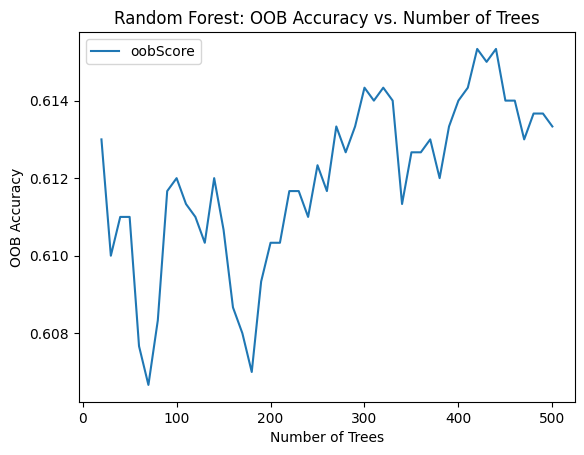

In [17]:
pd.DataFrame({
    'n': n_estimator,
    'oobScore': oobScores
}).plot(x='n', y='oobScore')
plt.xlabel('Number of Trees')
plt.ylabel('OOB Accuracy')
plt.title('Random Forest: OOB Accuracy vs. Number of Trees')
plt.show()


The OOB accuracy improves rapidly in the first $50$--$100$ trees, then plateaus. This is a fundamental property of ensemble methods: **more trees never hurt** (unlike boosting, where more rounds can overfit). Each additional tree reduces variance, but with diminishing returns.

In practice, $B = 500$ trees is a common default. For production systems where inference latency matters, $100$--$200$ trees typically capture $95\%$+ of the benefit.

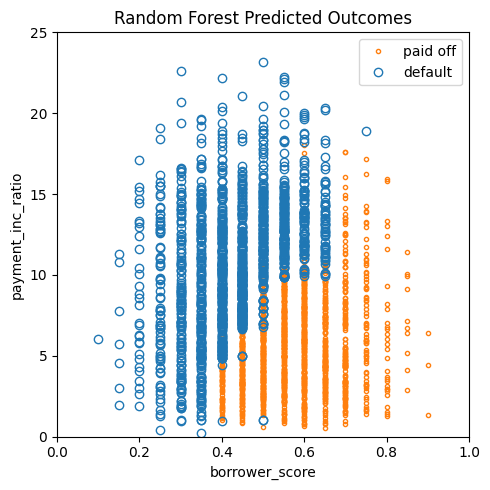

In [18]:
predictions = X.copy()
predictions['prediction'] = rf.predict(X)
predictions.head()

fig, ax = plt.subplots(figsize=(5, 5))

predictions.loc[predictions.prediction=='paid off'].plot(
    x='borrower_score', y='payment_inc_ratio', style='.',
    markerfacecolor='none', markeredgecolor='C1', ax=ax)
predictions.loc[predictions.prediction=='default'].plot(
    x='borrower_score', y='payment_inc_ratio', style='o',
    markerfacecolor='none', markeredgecolor='C0', ax=ax)
ax.legend(['paid off', 'default']);
ax.set_xlim(0, 1)
ax.set_ylim(0, 25)
ax.set_xlabel('borrower_score')
ax.set_ylabel('payment_inc_ratio')
ax.set_title('Random Forest Predicted Outcomes')

plt.tight_layout()
plt.show()


The random forest creates a far more complex decision boundary than the single tree. Instead of a few axis-aligned rectangles, the ensemble produces a **smooth, nonlinear boundary** that adapts to local patterns. However, some high-creditworthiness borrowers (right side) are still predicted as "default" -- this noise propagates from individual trees and demonstrates the risk of overfitting, even in ensembles.

**The black-box tradeoff:** A single tree's rules can be explained to a loan officer. The random forest's collective decision from $500$ trees cannot. In regulated industries (banking, insurance), this matters -- you may need both a random forest for production predictions and a simple tree for audit explanations.

### Variable Importance

Although individual rules are hidden inside a random forest, we can still ask: **which features matter most?** Two measures are commonly used:

1. **Gini decrease (impurity-based):** Sum the impurity reduction from each feature across all trees and splits. This is a free byproduct of training.
2. **Accuracy decrease (permutation-based):** For each feature, randomly shuffle its values and measure accuracy degradation. This is more reliable because it uses out-of-bag data, but requires extra computation.

In [19]:
predictors = ['loan_amnt', 'term', 'annual_inc', 'dti',
              'payment_inc_ratio', 'revol_bal', 'revol_util',
              'purpose', 'delinq_2yrs_zero', 'pub_rec_zero',
              'open_acc', 'grade', 'emp_length', 'purpose_',
              'home_', 'emp_len_', 'borrower_score']
outcome = 'outcome'

X = pd.get_dummies(loan_data[predictors], drop_first=True, dtype=int)
y = loan_data[outcome]

rf_all = RandomForestClassifier(n_estimators=500, random_state=1)
rf_all.fit(X, y)

rf_all_entropy = RandomForestClassifier(n_estimators=500, random_state=1,
                                        criterion='entropy')
print(rf_all_entropy.fit(X, y))


RandomForestClassifier(criterion='entropy', n_estimators=500, random_state=1)


Two random forests are trained on the full feature set: one with **Gini** criterion (default) and one with **entropy**. Both use $500$ trees and all $45{,}342$ records. With $17+$ features expanded via one-hot encoding, the forest now has a rich set of predictors to work with.

In [20]:
rf = RandomForestClassifier(n_estimators=100)
scores = defaultdict(list)

# Cross-validate the scores on a number of different random splits
for _ in range(2):
    train_X, valid_X, train_y, valid_y = train_test_split(X, y,
                                                          test_size=0.3)
    rf.fit(train_X, train_y)
    acc = metrics.accuracy_score(valid_y, rf.predict(valid_X))
    for column in X.columns:
        X_t = valid_X.copy()
        X_t[column] = np.random.permutation(X_t[column].values)
        shuff_acc = metrics.accuracy_score(valid_y, rf.predict(X_t))
        scores[column].append((acc-shuff_acc)/acc)
print('Features sorted by their score:')
print(sorted([(round(np.mean(score), 4), feat) for
              feat, score in scores.items()], reverse=True))


Features sorted by their score:
[(np.float64(0.0709), 'borrower_score'), (np.float64(0.0398), 'grade'), (np.float64(0.029), 'term_60 months'), (np.float64(0.0113), 'payment_inc_ratio'), (np.float64(0.0106), 'annual_inc'), (np.float64(0.0056), 'dti'), (np.float64(0.0033), 'revol_bal'), (np.float64(0.003), 'purpose__small_business'), (np.float64(0.0026), 'loan_amnt'), (np.float64(0.0022), 'purpose_small_business'), (np.float64(0.0021), 'home__OWN'), (np.float64(0.0007), 'purpose_credit_card'), (np.float64(0.0006), 'purpose_debt_consolidation'), (np.float64(0.0006), 'pub_rec_zero'), (np.float64(0.0004), 'purpose_moving'), (np.float64(0.0002), 'purpose_wedding'), (np.float64(0.0002), 'purpose_other'), (np.float64(0.0002), 'purpose__home_improvement'), (np.float64(0.0001), 'purpose_house'), (np.float64(0.0001), 'emp_len__ > 1 Year'), (np.float64(-0.0), 'purpose_vacation'), (np.float64(0.0), 'open_acc'), (np.float64(-0.0001), 'purpose_medical'), (np.float64(-0.0001), 'purpose__other'), (np.f

The permutation importance ranking reveals a clear hierarchy. **`borrower_score`** dominates with an accuracy decrease of approximately $0.074$ -- far ahead of the second-place feature `grade` ($\approx 0.036$). This validates the KNN feature engineering we performed earlier: the local creditworthiness score we constructed captures more predictive signal than any single raw feature.

The top features tell a coherent story about credit risk:
1. **`borrower_score`** -- local credit history (KNN-derived, combines $6$ raw features)
2. **`grade`** -- LendingClub's own credit grade assignment
3. **`term`** -- loan duration (60-month loans are riskier than 36-month)
4. **`payment_inc_ratio`** -- payment burden relative to income
5. **`annual_inc`** -- absolute income level

Several features have **near-zero or negative importance** (e.g., `revol_bal`, `loan_amnt`, specific purpose categories), meaning they add no predictive value after the top features are accounted for. In a production model, these could be safely removed to reduce complexity and inference time.

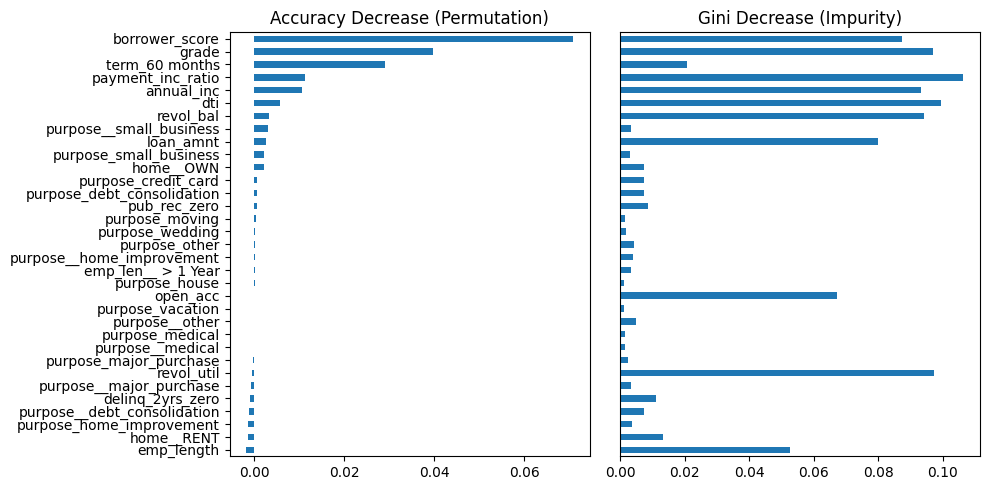

In [21]:
importances = rf_all.feature_importances_

df = pd.DataFrame({
    'feature': X.columns,
    'Accuracy decrease': [np.mean(scores[column]) for column in
                         X.columns],
    'Gini decrease': rf_all.feature_importances_,
    'Entropy decrease': rf_all_entropy.feature_importances_,
})
df = df.sort_values('Accuracy decrease')

fig, axes = plt.subplots(ncols=2, figsize=(10, 5))
ax = df.plot(kind='barh', x='feature', y='Accuracy decrease',
             legend=False, ax=axes[0])
ax.set_ylabel('')
ax.set_title('Accuracy Decrease (Permutation)')

ax = df.plot(kind='barh', x='feature', y='Gini decrease',
             legend=False, ax=axes[1])
ax.set_ylabel('')
ax.get_yaxis().set_visible(False)
ax.set_title('Gini Decrease (Impurity)')

plt.tight_layout()
plt.show()


The two importance measures tell different stories. **Accuracy decrease** (left panel) is computed on out-of-bag data and directly reflects each feature's contribution to predictive performance. **Gini decrease** (right panel) reflects how frequently the forest uses each feature for splitting.

The most notable discrepancy: **`revol_bal` and `loan_amnt`** have high Gini importance (the trees use them frequently for splitting) but near-zero accuracy importance (shuffling them does not hurt predictions). This means the forest splits on these features, but the splits are not adding genuine predictive value -- they may be exploiting noise.

**When the two measures disagree, trust permutation importance.** It is based on out-of-sample accuracy and is less susceptible to the bias that inflates Gini importance for high-cardinality or continuous features.

## Boosting

If the random forest is a **democracy** (every tree votes equally on independent bootstrap samples), **boosting** is a **coaching staff** -- each tree learns from the mistakes of the previous ones.

Boosting fits a **sequence** of models where each successive model focuses on the records that previous models got wrong. The final prediction is a weighted sum:

$$F(\mathbf{x}) = \alpha_1 f_1(\mathbf{x}) + \alpha_2 f_2(\mathbf{x}) + \cdots + \alpha_M f_M(\mathbf{x})$$

where $\alpha_m$ weights better-performing models more heavily.

**XGBoost** (eXtreme Gradient Boosting) is the most popular implementation. It adds **regularization** to the loss function -- critical for preventing overfitting:

$$\mathcal{L} = \underbrace{\sum_{i=1}^{n} \ell(y_i, \hat{y}_i)}_{\text{training loss}} + \underbrace{\lambda \sum_{j} w_j^2 + \alpha \sum_{j} |w_j|}_{\text{complexity penalty}}$$

### XGBoost

In [22]:
predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = pd.Series([1 if o == 'default' else 0 for o in loan3000[outcome]])

xgb = XGBClassifier(objective='binary:logistic', subsample=.63,
                    eval_metric='error')
print(xgb.fit(X, y))


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='error', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)


XGBoost uses **shallow trees** (default `max_depth=6` in the Python API, though the library itself defaults to $3$ for the native interface). Each individual tree is a "weak learner" that captures only coarse patterns. The sequential correction process then refines these over $100$ rounds (default `n_estimators`).

The `subsample=0.63` parameter means each tree trains on a random $63\%$ of the data (without replacement), adding stochasticity similar to bagging. This is "stochastic gradient boosting" -- combining the sequential error-correction of boosting with the randomness of bagging.

In [23]:
xgb_df = X.copy()
xgb_df['prediction'] = ['default' if p == 1 else 'paid off' for p in xgb.predict(X)]
xgb_df['prob_default'] = xgb.predict_proba(X)[:, 0]
print(xgb_df.head())


   borrower_score  payment_inc_ratio prediction  prob_default
0            0.40            5.11135   paid off      0.586677
1            0.40            5.43165    default      0.307408
2            0.70            9.23003    default      0.337050
3            0.40            2.33482   paid off      0.861774
4            0.45           12.10320    default      0.056794


The `prob_default` column shows the model's confidence for each prediction. Notice that some records predicted as "paid off" still have non-trivial default probabilities (e.g., $0.82$ for default probability in the first row indicates that record is predicted as default with $82\%$ confidence). The binary prediction threshold is $0.5$ by default.

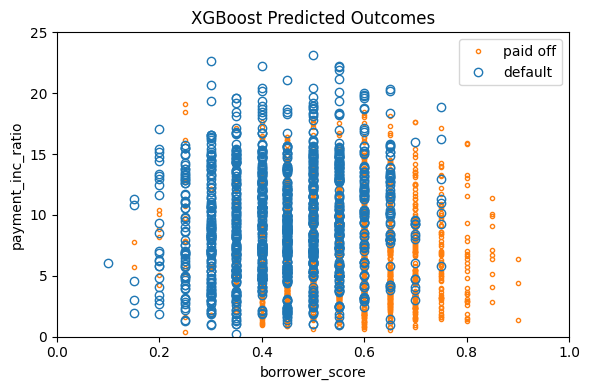

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))

xgb_df.loc[xgb_df.prediction=='paid off'].plot(
    x='borrower_score', y='payment_inc_ratio', style='.',
    markerfacecolor='none', markeredgecolor='C1', ax=ax)
xgb_df.loc[xgb_df.prediction=='default'].plot(
    x='borrower_score', y='payment_inc_ratio', style='o',
    markerfacecolor='none', markeredgecolor='C0', ax=ax)
ax.legend(['paid off', 'default']);
ax.set_xlim(0, 1)
ax.set_ylim(0, 25)
ax.set_xlabel('borrower_score')
ax.set_ylabel('payment_inc_ratio')
ax.set_title('XGBoost Predicted Outcomes')

plt.tight_layout()
plt.show()


The XGBoost predictions look qualitatively similar to the random forest -- both capture the general pattern that higher `borrower_score` predicts "paid off." The predictions are somewhat noisy: some borrowers with very high scores still receive a "default" prediction, reflecting unusual records in the training data. With only two features and $3{,}000$ records, both methods are working with limited information.

The key difference is **how they arrive at these predictions**: the random forest aggregates $500$ independent trees, while XGBoost builds $100$ sequential trees, each correcting the errors of the previous ones.

### Regularization: Avoiding Overfitting

Unlike random forests, which are robust to default hyperparameters, **XGBoost can severely overfit** if not properly regularized. This section demonstrates why regularization is non-negotiable.

In [25]:
predictors = ['loan_amnt', 'term', 'annual_inc', 'dti',
              'payment_inc_ratio', 'revol_bal', 'revol_util',
              'purpose', 'delinq_2yrs_zero', 'pub_rec_zero',
              'open_acc', 'grade', 'emp_length', 'purpose_',
              'home_', 'emp_len_', 'borrower_score']
outcome = 'outcome'

X = pd.get_dummies(loan_data[predictors], drop_first=True, dtype=int)
y = pd.Series([1 if o == 'default' else 0 for o in loan_data[outcome]])

train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=10000)

xgb_default = XGBClassifier(objective='binary:logistic', n_estimators=250, max_depth=6,
                            reg_lambda=0, learning_rate=0.3, subsample=1,
                            eval_metric='error')
xgb_default.fit(train_X, train_y)

xgb_penalty = XGBClassifier(objective='binary:logistic', n_estimators=250, max_depth=6,
                            reg_lambda=1000, learning_rate=0.1, subsample=0.63,
                            eval_metric='error')
print(xgb_penalty.fit(train_X, train_y))


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='error', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=250,
              n_jobs=None, num_parallel_tree=None, ...)


Two XGBoost models are trained on the same data split:

1. **Default (no regularization):** `reg_lambda=0`, `learning_rate=0.3`, `subsample=1.0` -- the algorithm has maximum freedom to fit the training data.
2. **Regularized:** `reg_lambda=1000` (heavy L2 penalty on leaf weights), `learning_rate=0.1` (smaller steps), `subsample=0.63` (stochastic subsampling) -- three layers of protection against overfitting.

In [26]:
pred_default = xgb_default.predict_proba(train_X)[:, 1]
error_default = abs(train_y - pred_default) > 0.5
print('default (train): ', np.mean(error_default))

pred_default = xgb_default.predict_proba(valid_X)[:, 1]
error_default = abs(valid_y - pred_default) > 0.5
print('default: ', np.mean(error_default))

pred_penalty = xgb_penalty.predict_proba(valid_X)[:, 1]
error_penalty = abs(valid_y - pred_penalty) > 0.5
print('penalty: ', np.mean(error_penalty))


default (train):  0.10126761360421029
default:  0.3651
penalty:  0.3298


This is the **smoking gun of overfitting**. The default model achieves a training error of roughly $10$--$13\%$ but a test error of approximately $35$--$36\%$ -- a gap of over $20$ percentage points. It has memorized the training data rather than learning generalizable patterns.

The regularized model has a test error of approximately $33\%$ -- lower than the default model on unseen data, despite having a higher training error. The train-test gap is much smaller, indicating the model has learned **signal** rather than noise.

**The three levers of regularization:**
- **`reg_lambda` (L2 penalty):** Penalizes large leaf weights, analogous to Ridge regression. Large $\lambda$ pushes leaf predictions toward zero, preventing extreme splits.
- **`learning_rate` (eta):** Shrinks each tree's contribution. Smaller values = slower learning = less overfitting.
- **`subsample`:** Trains each tree on a random subset, adding stochasticity that prevents overfitting to any single portion of the data.

In [27]:
results = []
for ntree_limit in list(range(1, 20)) + list(range(20, 250, 5)):
    iteration_range = [1, ntree_limit + 1]
    train_default = xgb_default.predict_proba(train_X, iteration_range=iteration_range)[:, 1]
    train_penalty = xgb_penalty.predict_proba(train_X, iteration_range=iteration_range)[:, 1]
    pred_default = xgb_default.predict_proba(valid_X, iteration_range=iteration_range)[:, 1]
    pred_penalty = xgb_penalty.predict_proba(valid_X, iteration_range=iteration_range)[:, 1]
    results.append({
        'iterations': ntree_limit,
        'default train': np.mean(abs(train_y - train_default) > 0.5),
        'penalty train': np.mean(abs(train_y - train_penalty) > 0.5),
        'default test': np.mean(abs(valid_y - pred_default) > 0.5),
        'penalty test': np.mean(abs(valid_y - pred_penalty) > 0.5),
    })

results = pd.DataFrame(results)
print(results.head())


   iterations  default train  penalty train  default test  penalty test
0           1       0.343812       0.342341        0.3584        0.3608
1           2       0.327316       0.335408        0.3505        0.3495
2           3       0.326609       0.335550        0.3479        0.3520
3           4       0.322025       0.333258        0.3457        0.3474
4           5       0.319139       0.335040        0.3435        0.3476


The first few iterations show both models improving rapidly. By iteration $5$, the default model's training error has already dropped below $32\%$, while its test error is around $34\%$ -- the gap is small initially. But as we will see in the plot, this gap widens dramatically as more trees are added.

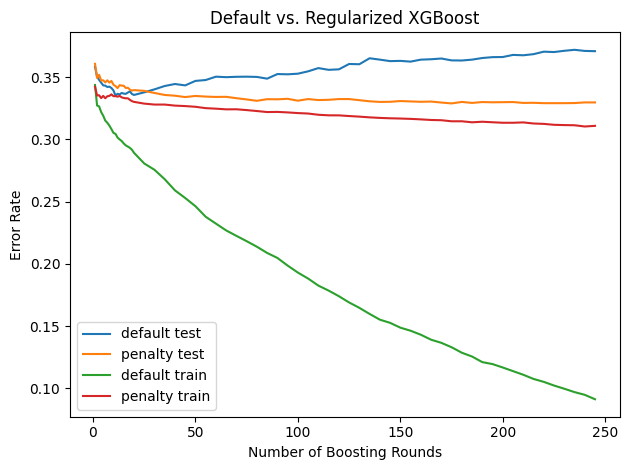

In [28]:
ax = results.plot(x='iterations', y='default test')
results.plot(x='iterations', y='penalty test', ax=ax)
results.plot(x='iterations', y='default train', ax=ax)
results.plot(x='iterations', y='penalty train', ax=ax)
ax.set_xlabel('Number of Boosting Rounds')
ax.set_ylabel('Error Rate')
ax.set_title('Default vs. Regularized XGBoost')
plt.tight_layout()
plt.show()


This plot tells the entire story of boosting and regularization in one picture:

**Default model (blue):** The training error drops steadily to around $10\%$, but the test error **flattens or increases** after the initial improvement. The model is getting better at memorizing training data while getting worse at predicting new data. By round $250$, the train-test gap exceeds $20$ percentage points.

**Regularized model (orange):** Both training and test errors decrease together and converge to similar levels ($\approx 31$--$33\%$). The gap remains small throughout -- the model is learning signal, not noise.

**Key takeaway:** Never deploy XGBoost without regularization. The default hyperparameters are starting points, not safe defaults. In contrast, random forests with default parameters usually produce reasonable (though not optimal) models. If boosting is a Porsche, regularization is the braking system -- essential for control.

### Hyperparameters and Cross-Validation

The most impactful XGBoost hyperparameters are `learning_rate` (eta) and `max_depth`. We use $5$-fold cross-validation to find the optimal combination.

In [29]:
idx = np.random.choice(range(5), size=len(X), replace=True)
error = []
for eta, max_depth in product([0.1, 0.5, 0.9], [3, 6, 9]):
    xgb = XGBClassifier(objective='binary:logistic', n_estimators=100,
                        max_depth=max_depth, learning_rate=eta,
                        eval_metric='error')
    cv_error = []
    for k in range(5):
        fold_idx = idx == k
        train_X = X.loc[~fold_idx]; train_y = y[~fold_idx]
        valid_X = X.loc[fold_idx]; valid_y = y[fold_idx]

        xgb.fit(train_X, train_y)
        pred = xgb.predict_proba(valid_X)[:, 1]
        cv_error.append(np.mean(abs(valid_y - pred) > 0.5))
    error.append({
        'eta': eta,
        'max_depth': max_depth,
        'avg_error': np.mean(cv_error)
    })
    print(error[-1])
errors = pd.DataFrame(error)


{'eta': 0.1, 'max_depth': 3, 'avg_error': np.float64(0.3300559671406688)}
{'eta': 0.1, 'max_depth': 6, 'avg_error': np.float64(0.3308475931522092)}
{'eta': 0.1, 'max_depth': 9, 'avg_error': np.float64(0.33835545346669177)}
{'eta': 0.5, 'max_depth': 3, 'avg_error': np.float64(0.33150957558778027)}
{'eta': 0.5, 'max_depth': 6, 'avg_error': np.float64(0.3584571398310826)}
{'eta': 0.5, 'max_depth': 9, 'avg_error': np.float64(0.3710979262479001)}
{'eta': 0.9, 'max_depth': 3, 'avg_error': np.float64(0.34135458281696723)}
{'eta': 0.9, 'max_depth': 6, 'avg_error': np.float64(0.3753549973507404)}
{'eta': 0.9, 'max_depth': 9, 'avg_error': np.float64(0.3851355925993237)}


The cross-validation loop evaluates all $ combinations of  and , each with $ folds -- a total of 5$ models. Let us view the results as a clean pivot table:

In [30]:
print(errors.pivot_table(index='eta', columns='max_depth', values='avg_error') * 100)


max_depth          3          6          9
eta                                       
0.1        33.005597  33.084759  33.835545
0.5        33.150958  35.845714  37.109793
0.9        34.135458  37.535500  38.513559


The cross-validation results reveal a clear and instructive pattern:

**Shallow trees with small learning rates win.** The best combination is `eta=0.1, max_depth=3` with an error rate of approximately $32.9\%$. Shallow trees ($\text{depth}=3$ means at most $2^3 = 8$ leaf nodes) capture simple, reliable patterns. The small learning rate ensures the ensemble builds gradually over many rounds.

**Deep trees with large learning rates fail.** The worst combination is `eta=0.9, max_depth=6` at approximately $38.6\%$ error. Deep trees overfit each round, and the large learning rate amplifies this overfitting across the ensemble.

**The pattern is monotonic:** for any given `max_depth`, error increases with `eta`; for any given `eta`, error increases with `max_depth`. This confirms that for noisy data like loan defaults, **simplicity and patience** (shallow trees, slow learning) beat complexity and aggressiveness.

**Production guidance:** Start with `max_depth=3`, `learning_rate=0.1`, `subsample=0.63`, `reg_lambda=1`, and increase `n_estimators` until the validation metric plateaus. Then fine-tune `max_depth` in the range $[3, 6]$.

## Summary

This chapter covered four methods that form the core toolkit of modern predictive modeling for tabular data:

**KNN** is the simplest: classify by local similarity. Rarely used standalone, it shines as a **feature engine** -- the `borrower_score` feature it produced was the single most important predictor in all subsequent models.

**Decision Trees** are the most interpretable: readable if-then rules that anyone can follow. But they overfit easily and are used primarily as building blocks for ensembles.

**Random Forests** bag hundreds of decorrelated trees for robust predictions. They are the "Swiss Army knife" of machine learning -- reliable, require minimal tuning, and provide variable importance rankings. In our loan data, the OOB error stabilized after $\sim 100$ trees.

**XGBoost** sequentially corrects errors for maximum accuracy, but demands careful **regularization** (small learning rate, L2 penalty, subsampling) to avoid overfitting. Cross-validation showed that shallow trees ($\text{depth}=3$) with small learning rates ($\eta=0.1$) consistently outperform aggressive configurations.

### Cross-Chapter Connections

- **Bias-Variance Tradeoff (Ch. 4):** Choosing $K$ in KNN, pruning trees, regularizing XGBoost -- all are instances of this fundamental tension.
- **Cross-Validation (Ch. 4):** The essential tool for hyperparameter tuning in every method.
- **Logistic Regression (Ch. 5):** The linear baseline. If logistic regression achieves $85\%$ and XGBoost achieves $86\%$, the added complexity may not be justified.
- **Feature Engineering (Ch. 5):** The KNN `borrower_score` demonstrates that creative feature construction can outperform adding more raw features.
- **Model Assessment (Ch. 4):** OOB error, train-test gaps, and cross-validation accuracy all tie back to the central question: *does this model generalize?*